# Cox (semiparametric proportional hazard)

This demonstration requires 2 optional dependencies : [pandas](https://pypi.org/project/pandas/) and [lifelines](https://pypi.org/project/lifelines/). Install them if you wish to reproduce examples outputs. Otherwise, below examples may help you to understand how you can use Cox model with ReLife.

### Loading data

Let's use a [lifelines](https://pypi.org/project/lifelines/) dataset.

In [1]:
import lifelines
import pandas as pd

In [2]:
df = lifelines.datasets.load_canadian_senators()

Clean up the dataset

In [3]:
df = df[["Name", "Province / Territory", "reason", "diff_days", "observed"]]
df = df[df["reason"] != "Appointment declined"]
# standardize text (removing white spaces, non alphanumeric characters and put in lower case)
df["Province / Territory"] = (
    df["Province / Territory"].str.replace("\W+", "", regex=True).str.lower()
)
display(df.head())

,Name,Province / Territory,reason,diff_days,observed
0,"Abbott, John Joseph Caldwell",quebec,Death,2363,True
1,"Adams, Michael",newbrunswick,Death,1090,True
2,"Adams, Willie",northwestterritories,Retirement,11766,True
3,"Aikins, James Cox",ontario,Resignation,5333,True
4,"Aikins, James Cox",ontario,Death,3133,True


In [4]:
df["Province / Territory"].value_counts()

Province / Territory
quebec                      246
ontario                     242
novascotia                   98
newbrunswick                 93
britishcolumbia              44
manitoba                     44
alberta                      43
princeedwardisland           39
saskatchewan                 32
newfoundlandandlabrador      30
northwestterritories          7
yukon                         3
westernprovincesdivision      2
maritimesdivision             2
quebecdivision                2
ontariodivision               2
nunavut                       1
Name: count, dtype: int64

Dummy encoding of "Province / Territory" covariates

In [5]:
# dummy encoding of "Province / Territory"
df = pd.get_dummies(df, columns=["Province / Territory"], prefix="covar", dtype=int)
# remove covariate columns corresponding to low count province
covar_cols = [col for col in df.columns if "covar" in col]
province_count = df[covar_cols].sum()
province_with_low_count = province_count[province_count < 10]
df = df.drop(columns=province_with_low_count.index)

In [6]:
print(df.columns)

Index(['Name', 'reason', 'diff_days', 'observed', 'covar_alberta',
       'covar_britishcolumbia', 'covar_manitoba', 'covar_newbrunswick',
       'covar_newfoundlandandlabrador', 'covar_novascotia', 'covar_ontario',
       'covar_princeedwardisland', 'covar_quebec', 'covar_saskatchewan'],
      dtype='object')


### Fitting

Lifelines version

In [7]:
from lifelines.fitters.coxph_fitter import CoxPHFitter
# Lifelines model fit

covar_cols = [col for col in df.columns if "covar" in col]
ll_model = CoxPHFitter()
ll_model.fit(
    df=df,
    duration_col="diff_days",
    event_col="observed",
    formula="~ " + " + ".join(covar_cols),
)
print(ll_model.params_)

covariate
covar_alberta                    0.345928
covar_britishcolumbia            0.173319
covar_manitoba                   0.292570
covar_newbrunswick               0.193955
covar_newfoundlandandlabrador    0.444993
covar_novascotia                 0.266590
covar_ontario                    0.319706
covar_princeedwardisland         0.397880
covar_quebec                     0.344936
covar_saskatchewan              -0.049557
Name: coef, dtype: float64


<Axes: xlabel='time', ylabel='sf'>

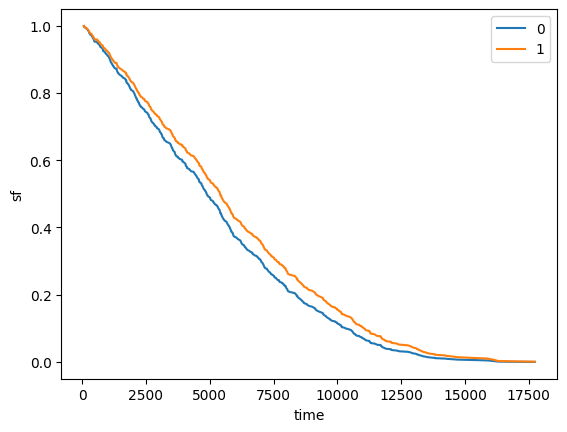

In [8]:
# Lifelines sf
max_offset = 0

X = df.filter(regex="covar").iloc[:2]

sf_lifelines = ll_model.predict_survival_function(
    X=X,
    times=range(
        df["diff_days"].min().astype(int),
        df["diff_days"].max().astype(int) + max_offset,
    ),
)

sf_lifelines.columns = X.index
sf_lifelines.plot(xlabel="time", ylabel="sf")

ReLife version 

In [9]:
from relife.lifetime_models import SemiParametricProportionalHazard

cox_model = SemiParametricProportionalHazard()
cox_model.fit(
    df["diff_days"].to_numpy(),
    covar=df.filter(regex="covar").to_numpy(),
    event=df["observed"].to_numpy(dtype=bool),
)

In [10]:
timeline, sf_values = cox_model.sf(covar=X, se=False)

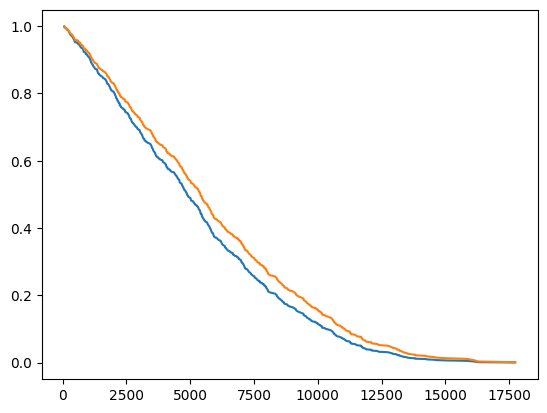

In [11]:
import matplotlib.pyplot as plt

plt.plot(timeline, sf_values[0])
plt.plot(timeline, sf_values[1])